# Ejercicio 2 — Cálculo de Itô y martingalas

**Máster Executive en Finanzas Cuantitativas 2026 · AFI Global Education**  
**Asignatura:** Fundamentos matemáticos — Procesos estocásticos

---

## Objetivo

1. determinar el drift que convierte el cociente $X_t/N_t$ en martingala;
2. resolver una integral de Itô mediante la dinámica de $W_t^3$;
3. demostrar que un cuadrado compensado es martingala, obtener su ley y verificarla por simulación.

Se distingue en todo momento entre una identidad analítica, una aproximación temporal de una integral de Itô y el error puramente Monte Carlo.


## Configuración del entorno


**Ejecución:** Python 3, NumPy, pandas, Matplotlib y SciPy; Jupyter/IPython para visualizar. Reiniciar el kernel y ejecutar todas las celdas en orden. No se leen ni escriben archivos auxiliares. Las semillas están fijadas y las figuras quedan embebidas en el notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy.stats import chi2, kstest
from IPython.display import display

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "legend.fontsize": 10,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.prop_cycle": plt.cycler(color=["#001391", "#1973b8", "#5e9cc9"]),
    "axes.grid": True,
    "grid.alpha": 0.15,
    "axes.titleweight": "bold",
})

T = 1.0
print("Horizonte de las comprobaciones numéricas: T = 1 año")


Horizonte de las comprobaciones numéricas: T = 1 año


### Mapa conceptual del ejercicio 2

Los tres apartados usan la misma herramienta —Itô— con objetivos distintos:

$$
\boxed{
\text{2.a: dinámica de un cociente}
\quad\to\quad
\text{2.b: transformar una integral}
\quad\to\quad
\text{2.c: compensar un cuadrado}
}
$$

La regla de trabajo será siempre la misma: **primero decidir qué proceso auxiliar conviene definir, después aplicar Itô y finalmente interpretar el término de deriva y el término aleatorio**.


## 2.a — Elegir la deriva para que el cociente sea martingala

### Antes de derivar: qué estamos intentando conseguir

Definimos

$$
Y_t=\frac{X_t}{N_t}.
$$

No vamos a adivinar $\mu$. El plan es:

$$
\boxed{
Y_t=\frac{X_t}{N_t}
\longrightarrow dY_t
\longrightarrow \text{identificar su término }dt
\longrightarrow \text{elegir }\mu\text{ para anularlo}
}
$$

Para una martingala queremos eliminar la **deriva predecible**, es decir, el coeficiente de $dt$. El ruido browniano puede permanecer.

Al aplicar Itô a $h(x,n)=x/n$ aparecerán cuatro contribuciones con significados distintos:

1. el movimiento de $X_t$;
2. el movimiento de $N_t$;
3. la curvatura de $1/N_t$;
4. la covariación entre los dos ruidos.

La cuarta es la razón por la que no basta con “restar las derivas” de numerador y denominador.


Dados

$$dX_t=\mu X_t\,dt+\sigma X_t\,dW_t^{(1)},\qquad
dN_t=\frac12N_t\,dt+N_t\,dW_t^{(2)},$$

con $d\langle W^{(1)},W^{(2)}\rangle_t=\rho\,dt$, buscamos $\mu$ para que $Y_t=X_t/N_t$ sea martingala. $\sigma$ es la volatilidad de $X$; $\rho\in[-1,1]$ mide la correlación entre los ruidos.

**Idea.** El cociente debe quedar sin deriva, pero no basta restar las derivas de $X$ y $N$: la curvatura del cociente y la correlación generan correcciones de Itô. Después comprobaremos que la martingala es verdadera, no solo local.

Tomamos valores iniciales deterministas, $N_0>0$ y $X_0\ne0$. Como $N_t=N_0e^{W_t^{(2)}}>0$, podemos dividir. Si $X_0=0$, el cociente es cero y cualquier $\mu$ sirve.

### Aplicar Itô al cociente

Para $h(x,n)=x/n$,

$$h_x=\frac1n,\quad h_n=-\frac{x}{n^2},\quad
h_{xx}=0,\quad h_{nn}=\frac{2x}{n^3},\quad h_{xn}=-\frac1{n^2}.$$

La notación $\langle X,N\rangle$ representa la covariación cuadrática. Itô da

$$dY_t=h_x\,dX_t+h_n\,dN_t
+\frac12h_{nn}\,d\langle N\rangle_t
+h_{xn}\,d\langle X,N\rangle_t.$$

El término con $h_{xx}$ es cero. El término cruzado no lleva $1/2$: suma las dos contribuciones simétricas. Sustituimos cada parte:

$$h_x\,dX_t=\mu Y_t\,dt+\sigma Y_t\,dW_t^{(1)},$$

$$h_n\,dN_t=-\frac12Y_t\,dt-Y_t\,dW_t^{(2)}.$$

Como $d\langle N\rangle_t=N_t^2dt$, la curvatura de $1/n$ añade

$$\frac12h_{nn}\,d\langle N\rangle_t
=\frac12\frac{2X_t}{N_t^3}N_t^2dt=Y_t\,dt.$$

La correlación aporta $d\langle X,N\rangle_t=\sigma\rho X_tN_tdt$ y, por tanto,

$$h_{xn}\,d\langle X,N\rangle_t=-\sigma\rho Y_t\,dt.$$

Agrupando,

$$dY_t=Y_t\left[\left(\mu+\frac12-\sigma\rho\right)dt
+\sigma\,dW_t^{(1)}-dW_t^{(2)}\right].$$

Anular la deriva exige

$$\boxed{\mu=\sigma\rho-\frac12}.$$

### Por qué es una martingala verdadera

Sea $q=\sigma^2+1-2\sigma\rho\ge0$, la tasa de varianza del ruido combinado. Con el valor anterior de $\mu$,

$$Y_t=Y_0\exp\left(\sigma W_t^{(1)}-W_t^{(2)}-\frac12qt\right).$$

Entre $s$ y $t$, el incremento del ruido es independiente de $\mathcal F_s$ —la información disponible hasta $s$— y normal de varianza $q(t-s)$. La esperanza de su exponencial es $e^{q(t-s)/2}$, exactamente compensada por el término negativo. Así,

$$E[|Y_t|]=|Y_0|<\infty,\qquad E[Y_t\mid\mathcal F_s]=Y_s.$$

Si $q=0$, el ruido se cancela y $Y_t=Y_0$.

**Qué muestra la gráfica.** Usamos $\sigma=0.30$, $\rho=0.40$ y $Y_0=1$ como ejemplo, no como datos del enunciado. Arriba, cada trayectoria fluctúa; abajo, la media se compara con uno. La banda es un intervalo Monte Carlo puntual del 95 %, no una banda que deba contener todas las fechas simultáneamente.


Ejemplo: sigma=0.30, rho=0.40
mu = sigma*rho - 1/2 = -0.3800
q = sigma² + 1 - 2*sigma*rho = 0.8500
Máximo desvío de E[Y_t]=Y_0 en unidades de SE: 2.09


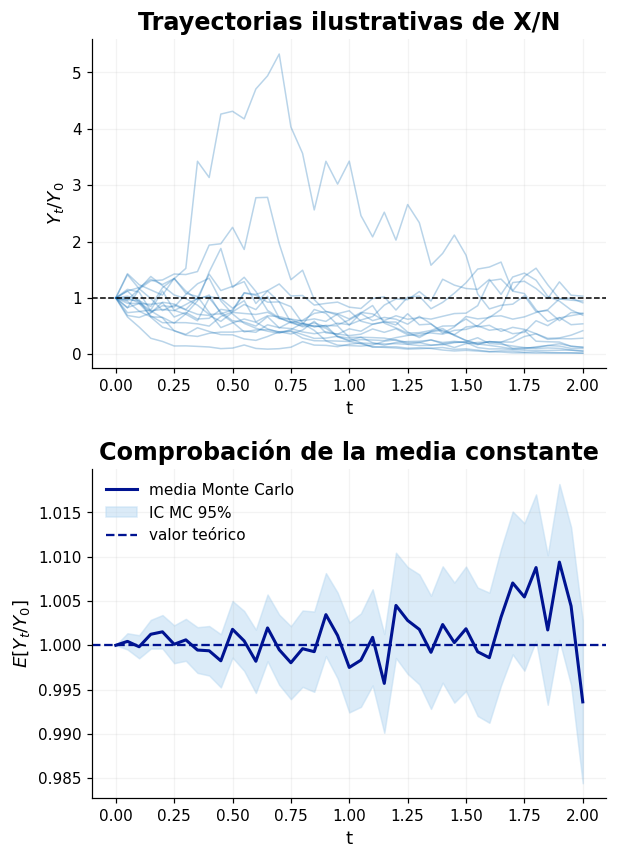

In [2]:
# Comprobación numérica ilustrativa; sigma y rho no están fijados en el enunciado.
sigma_demo = 0.30
rho_demo = 0.40
mu_demo = sigma_demo * rho_demo - 0.50
q_demo = sigma_demo**2 + 1.0 - 2.0 * sigma_demo * rho_demo
assert q_demo >= 0.0

t_grid = np.linspace(0.0, 2.0, 41)
n_mc = 200_000
rng = np.random.default_rng(20260201)
z = rng.standard_normal((n_mc, len(t_grid) - 1))
y_marginal = np.ones((n_mc, len(t_grid)))
y_marginal[:, 1:] = np.exp(
    -0.5 * q_demo * t_grid[1:]
    + np.sqrt(q_demo * t_grid[1:]) * z
)
media_mc = y_marginal.mean(axis=0)
se_mc = y_marginal.std(axis=0, ddof=1) / np.sqrt(n_mc)
z_media = np.divide(
    media_mc - 1.0, se_mc,
    out=np.zeros_like(media_mc), where=se_mc > 0,
)
assert np.max(np.abs(z_media)) < 5.5

# Trayectorias coherentes temporalmente del browniano efectivo.
n_paths_plot = 16
rng_paths = np.random.default_rng(20260202)
dt = t_grid[1] - t_grid[0]
B = np.c_[np.zeros(n_paths_plot),
          np.cumsum(np.sqrt(dt) * rng_paths.standard_normal(
              (n_paths_plot, len(t_grid) - 1)), axis=1)]
y_paths = np.exp(-0.5 * q_demo * t_grid + np.sqrt(q_demo) * B)

print(f"Ejemplo: sigma={sigma_demo:.2f}, rho={rho_demo:.2f}")
print(f"mu = sigma*rho - 1/2 = {mu_demo:.4f}")
print(f"q = sigma² + 1 - 2*sigma*rho = {q_demo:.4f}")
print(f"Máximo desvío de E[Y_t]=Y_0 en unidades de SE: "
      f"{np.max(np.abs(z_media)):.2f}")

fig, axes = plt.subplots(2, 1, figsize=(5.8, 8.0))
axes[0].plot(t_grid, y_paths.T, color="#1973b8", alpha=0.30, lw=1)
axes[0].axhline(1.0, color="black", ls="--", lw=1)
axes[0].set(title="Trayectorias ilustrativas de X/N",
            xlabel="t", ylabel="$Y_t/Y_0$")

axes[1].plot(t_grid, media_mc, color="#001391", lw=2, label="media Monte Carlo")
axes[1].fill_between(t_grid, media_mc - 1.96*se_mc, media_mc + 1.96*se_mc,
                     color="#b9d9f2", alpha=0.5, label="IC MC 95%")
axes[1].axhline(1.0, color="#001391", ls="--", lw=1.5,
                label="valor teórico")
axes[1].set(title="Comprobación de la media constante",
            xlabel="t", ylabel="$E[Y_t/Y_0]$")
axes[1].legend()
fig.tight_layout()
plt.show()


## 2.b — Resolver una integral buscando su dinámica

### Antes de aplicar Itô: cómo se nos ocurre qué función usar

Queremos simplificar una integral que contiene $W_t^2\,dW_t$. La pregunta útil no es “¿qué fórmula recuerdo?”, sino:

> ¿Existe una función cuya derivada respecto a $W$ sea $W^2$?

Sí:

$$
f'(w)=w^2
\quad\Longrightarrow\quad
f(w)=\frac{w^3}{3}.
$$

Por eso probamos Itô sobre $W_t^3/3$: su primer término diferencial producirá exactamente $W_t^2\,dW_t$, y la corrección de segundo orden nos dirá qué término adicional aparece.

Esta es una regla útil: cuando veas una integral de la forma $\int g(W_t)\,dW_t$, intenta encontrar una primitiva de $g$ y aplicar Itô.

Para $\int t\,dW_t$ la lógica es distinta: el integrando depende del tiempo. Probamos el producto $tW_t$ porque su diferencial contiene precisamente el término $t\,dW_t$ que queremos aislar.


Queremos expresar, para un browniano con $W_0=0$,

$$I_t=\int_0^t(W_s^2-s)\,dW_s.$$

**Idea.** La pista $W_t^3$ funciona porque su derivada contiene $W_t^2$. Separaremos la integral y combinaremos Itô con la regla del producto:

$$I_t=\int_0^tW_s^2\,dW_s-\int_0^ts\,dW_s.$$

### Itô para la primera parte

Con $f(w)=w^3/3$, $f'(w)=w^2$ y $f''(w)=2w$,

$$d\left(\frac{W_t^3}{3}\right)=W_t^2\,dW_t+W_t\,dt.$$

El segundo término es la corrección de Itô. Despejar e integrar da

$$\int_0^tW_s^2\,dW_s=\frac{W_t^3}{3}-\int_0^tW_s\,ds.$$

### Regla del producto para la segunda

El tiempo tiene variación finita, luego $d\langle t,W\rangle_t=0$. Por eso,

$$d(tW_t)=W_t\,dt+t\,dW_t,$$

$$\int_0^ts\,dW_s=tW_t-\int_0^tW_s\,ds.$$

Al restar, las dos integrales ordinarias de $W_s$ se cancelan:

$$\boxed{I_t=\frac{W_t^3}{3}-tW_t}.$$

La comprobación es directa: el diferencial del resultado es $(W_t^2-t)dW_t$ y su valor inicial es cero.

### Qué comprueba la simulación

De $E[W_s^2]=s$ y $E[W_s^4]=3s^2$ obtenemos
$E[(W_s^2-s)^2]=2s^2$. La isometría de Itô da

$$E[I_t]=0,\qquad\operatorname{Var}(I_t)=\int_0^t2s^2\,ds=\frac{2t^3}{3}.$$

El código evalúa el integrando **antes** del siguiente incremento: son sumas por la izquierda. La gráfica compara esa aproximación con la expresión exacta sobre una misma trayectoria. El segundo panel muestra cómo disminuye el RMSE —raíz del error cuadrático medio— al reducir el paso $\Delta t$. Hay error de discretización en la suma, no en la identidad.


In [3]:
def error_integral_ito(n_steps, n_paths=40_000, seed=0):
    '''Aproxima la integral con sumas de Itô por la izquierda.'''
    dt = T / n_steps
    rng = np.random.default_rng(seed)
    W = np.zeros(n_paths)
    I_riemann = np.zeros(n_paths)
    for j in range(n_steps):
        s = j * dt
        dW = np.sqrt(dt) * rng.standard_normal(n_paths)
        I_riemann += (W**2 - s) * dW
        W += dW
    I_cerrada = W**3 / 3.0 - T * W
    diferencia = I_riemann - I_cerrada
    return {
        "Pasos": n_steps,
        "dt": dt,
        "RMSE identidad": np.sqrt(np.mean(diferencia**2)),
        "Sesgo identidad": diferencia.mean(),
        "Media I cerrada": I_cerrada.mean(),
        "Varianza I cerrada": I_cerrada.var(ddof=1),
    }

tabla_conv = pd.DataFrame([
    error_integral_ito(50, seed=2050),
    error_integral_ito(200, seed=2200),
    error_integral_ito(800, seed=2800),
]).set_index("Pasos")

assert np.all(np.diff(tabla_conv["RMSE identidad"].values) < 0)
assert abs(tabla_conv.loc[800, "Varianza I cerrada"] - 2/3) < 0.03

display(tabla_conv.style.format({
    "dt": "{:.5f}", "RMSE identidad": "{:.6f}",
    "Sesgo identidad": "{:+.6f}", "Media I cerrada": "{:+.6f}",
    "Varianza I cerrada": "{:.6f}",
}))
print(f"Varianza teórica en t=1: {2/3:.6f}")


,dt,RMSE identidad,Sesgo identidad,Media I cerrada,Varianza I cerrada
Pasos,,,,,
50,0.02000,0.140808,+0.000344,-0.000841,0.650274
200,0.00500,0.070856,-0.000082,+0.002658,0.643326
800,0.00125,0.035489,-0.000333,+0.004753,0.651426


Varianza teórica en t=1: 0.666667


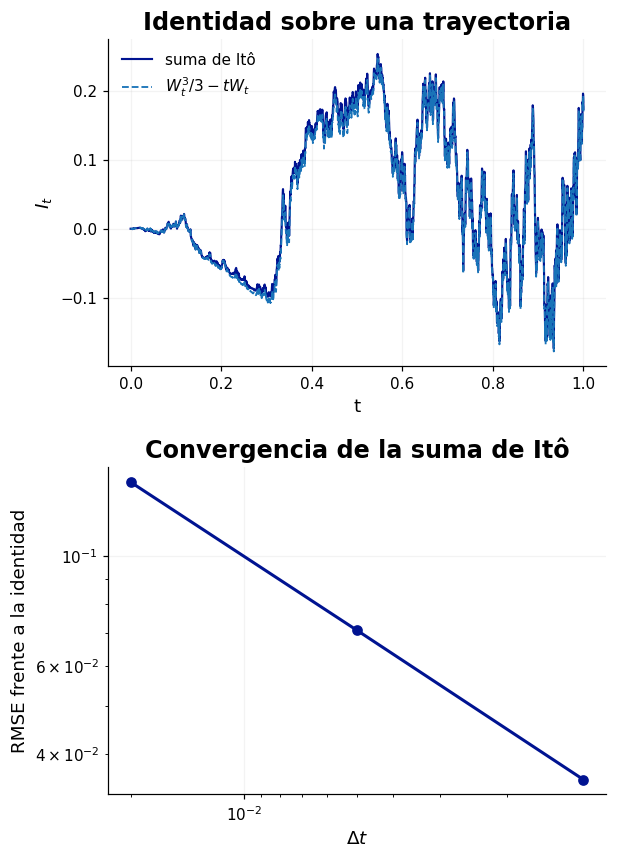

In [4]:
# Una trayectoria: suma de Itô frente a la expresión cerrada en todo el intervalo.
n_steps = 2_000
dt = T / n_steps
rng = np.random.default_rng(20260203)
W = 0.0
I_sum = 0.0
trayectoria_W = [0.0]
trayectoria_sum = [0.0]
trayectoria_cerrada = [0.0]
for j in range(n_steps):
    s = j * dt
    dW = np.sqrt(dt) * rng.standard_normal()
    I_sum += (W**2 - s) * dW
    W += dW
    t_now = (j + 1) * dt
    trayectoria_W.append(W)
    trayectoria_sum.append(I_sum)
    trayectoria_cerrada.append(W**3/3.0 - t_now*W)

fig, axes = plt.subplots(2, 1, figsize=(5.8, 8.0))
tiempos = np.linspace(0, T, n_steps + 1)
axes[0].plot(tiempos, trayectoria_sum, lw=1.4, label="suma de Itô")
axes[0].plot(tiempos, trayectoria_cerrada, lw=1.2, ls="--",
             label="$W_t^3/3-tW_t$")
axes[0].set(title="Identidad sobre una trayectoria", xlabel="t", ylabel="$I_t$")
axes[0].legend()

axes[1].loglog(tabla_conv["dt"], tabla_conv["RMSE identidad"],
               marker="o", lw=2, color="#001391")
axes[1].invert_xaxis()
axes[1].set(title="Convergencia de la suma de Itô",
            xlabel="$\\Delta t$", ylabel="RMSE frente a la identidad")
fig.tight_layout()
plt.show()


---

## Apartado 2.c.1 — Por qué compensamos el cuadrado y cómo probar que es martingala

### Idea antes de demostrarla: por qué aparece un “cuadrado compensado”

Sea

$$
A_t=\int_0^t s\,dW_s.
$$

$A_t$ es una martingala centrada, pero $A_t^2$ ya no lo es: al cuadrar aparece crecimiento sistemático debido a la variabilidad acumulada del proceso. Itô hará visible ese crecimiento como un término de deriva.

La idea es restarlo exactamente:

$$
\boxed{
A_t
\longrightarrow A_t^2
\longrightarrow \text{Itô introduce deriva}
\longrightarrow A_t^2-\langle A\rangle_t
\longrightarrow \text{martingala}
}
$$

Aquí $\langle A\rangle_t$ mide la variación cuadrática acumulada de $A$. En este ejercicio resultará ser $t^3/3$.


**Qué pide el enunciado.** Para el proceso

$$M_t=\left(\int_0^t s\,dW_s\right)^2-\frac{t^3}{3},$$

describir dos maneras de probar que es martingala y elegir una para desarrollar. Usaremos Itô como demostración principal y dejaremos la esperanza condicional como una comprobación alternativa breve.

### 1. Antes de demostrar: ¿por qué restamos $t^3/3$?

Llamamos

$$A_t=\int_0^t s\,dW_s.$$

Esta integral de Itô es una martingala centrada: $E[A_t]=0$. Como el integrando $s$ es determinista, $A_t$ también es gaussiano. Sin embargo, media cero no significa dispersión constante: su varianza crece con el tiempo. La isometría de Itô permite cuantificar ese crecimiento:

$$E[A_t^2]=\operatorname{Var}(A_t)=\int_0^t s^2\,ds=\frac{t^3}{3}.$$

Por eso $A_t^2$ ya no es una martingala: su esperanza aumenta, mientras que una martingala integrable conserva su esperanza. El proceso del enunciado tiene una intención concreta:

$$M_t=A_t^2-\frac{t^3}{3}.$$

Es el cuadrado de $A_t$ al que le quitamos exactamente su crecimiento esperado. Esto explica la construcción, pero tener esperanza cero no basta para demostrar que es martingala; a continuación comprobaremos su dinámica.

Ahora introducimos la notación que resume esa compensación:

$$q_t:=\frac{t^3}{3}=E[A_t^2]=\langle A\rangle_t.$$

Aquí la variación cuadrática $\langle A\rangle_t$ es determinista y coincide con la varianza de $A_t$: acumula el cuadrado del coeficiente que multiplica a $dW_t$. La idea que verificaremos es:

$$\boxed{A_t^2\text{ adquiere deriva}\ \Rightarrow
A_t^2-\langle A\rangle_t\text{ elimina esa deriva}}.$$

### 2. Método principal: Itô muestra la cancelación

Partimos de $dA_t=t\,dW_t$. Para $f(a)=a^2$, tenemos $f'(a)=2a$ y $f''(a)=2$. La fórmula de Itô da

$$d(A_t^2)=2A_t\,dA_t+d\langle A\rangle_t.$$

Como $d\langle A\rangle_t=t^2\,dt$, al sustituir resulta

$$d(A_t^2)=2tA_t\,dW_t+t^2\,dt.$$

El cuadrado ha incorporado la deriva $t^2\,dt$. Por otro lado,

$$d\left(\frac{t^3}{3}\right)=t^2\,dt.$$

Al restar ambas dinámicas,

$$dM_t=(2tA_t\,dW_t+t^2\,dt)-t^2\,dt,$$

$$\boxed{dM_t=2tA_t\,dW_t}.$$

El término $t^3/3$ está construido exactamente para cancelar el $t^2\,dt$ que aparece al cuadrar la martingala $A_t$.

**De martingala local a martingala verdadera.** Como $M_0=0$,

$$M_t=\int_0^t2sA_s\,dW_s.$$

Para poder afirmar que esta integral es una martingala verdadera, comprobamos que su integrando tiene segundo momento integrable en cualquier horizonte finito $T$:

$$E\left[\int_0^T(2sA_s)^2\,ds\right]
=4\int_0^Ts^2E[A_s^2]\,ds,$$

$$4\int_0^Ts^2\frac{s^3}{3}\,ds
=\frac43\int_0^Ts^5\,ds=\frac{2T^6}{9}<\infty.$$

El integrando es adaptado y continuo. Esta cota garantiza que $M_t$ es una martingala cuadrado integrable, no solo una martingala local sin deriva.

#### Método alternativo: esperanza condicional

Para $0\le s<t$, separamos el pasado del incremento futuro:

$$A_t=A_s+\int_s^t u\,dW_u.$$

El incremento es independiente de la información $\mathcal F_s$, tiene esperanza condicionada cero y varianza $\int_s^tu^2\,du=(t^3-s^3)/3$. Al desarrollar el cuadrado, el término cruzado desaparece al condicionar y queda

$$E[A_t^2\mid\mathcal F_s]=A_s^2+\frac{t^3-s^3}{3}.$$

El aumento de varianza queda exactamente compensado al restar $t^3/3$:

$$E[M_t\mid\mathcal F_s]
=A_s^2+\frac{t^3-s^3}{3}-\frac{t^3}{3}
=A_s^2-\frac{s^3}{3}=M_s.$$

La integrabilidad también se ve directamente: $E[|M_t|]\le E[A_t^2]+q_t=2q_t<\infty$. Ambas vías explican la misma compensación: Itô elimina la deriva y la esperanza condicional elimina el crecimiento esperado desde $s$ hasta $t$.


## Apartado 2.c.2 — Del cuadrado de una normal a la distribución de $M_t$

### Cambiamos de pregunta: dinámica frente a distribución

En 2.c.1 demostramos cómo evoluciona $M_t$ en el tiempo y por qué es martingala. Ahora fijamos una fecha $t$ y preguntamos **qué distribución tiene**. Son dos niveles distintos: una propiedad dinámica del proceso y una ley marginal en un instante.


**Qué pide el enunciado.** Identificar la ley de $M_t$ y calcular su esperanza y varianza. La demostración anterior explica cómo evoluciona; ahora miramos su distribución en una fecha fija.

### 1. Transformar la distribución que ya conocemos

Sabemos que $A_t\sim N(0,t^3/3)$. Para $t>0$, su ley puede escribirse con una normal estándar $Z\sim N(0,1)$:

$$A_t\overset d=\sqrt{\frac{t^3}{3}}\,Z.$$

Al elevar al cuadrado, la raíz desaparece:

$$A_t^2\overset d=\frac{t^3}{3}Z^2.$$

Como $Z^2$ sigue una chi-cuadrado con un grado de libertad, escribimos $U=Z^2\sim\chi_1^2$. Restar la compensación da

$$\boxed{M_t\overset d=\frac{t^3}{3}(U-1),\qquad U\sim\chi_1^2}.$$

La distribución de $M_t$ no es normal: estamos tomando el cuadrado de una normal y desplazándolo para que tenga media cero. Es asimétrica, con cola hacia valores positivos y soporte $[-t^3/3,\infty)$, porque $U\ge0$. En $t=0$, $M_0=0$ con probabilidad uno.

El símbolo $\overset d=$ significa igualdad en distribución en esa fecha; no autoriza a compartir una sola $Z$ entre todas las fechas para simular una trayectoria.

### 2. Leer la media y la varianza a partir de la transformación

La chi-cuadrado anterior tiene $E[U]=1$ y $\operatorname{Var}(U)=2$, pues $E[Z^2]=1$ y $E[Z^4]=3$. Usando $q_t=t^3/3$,

$$E[M_t]=q_t(E[U]-1)=0.$$

Restar una constante no cambia la varianza; multiplicar por $q_t$ la multiplica por $q_t^2$:

$$\operatorname{Var}(M_t)=q_t^2\operatorname{Var}(U)
=2q_t^2=\frac{2t^6}{9}.$$

Así, la compensación conserva la media en cero, pero no impide que la dispersión de $M_t$ crezca. Su varianza coincide con la cota calculada por isometría en la demostración anterior.

### 3. Referencia para la comprobación en $t=1$

$$M_1\overset d=\frac{U-1}{3},\qquad U\sim\chi_1^2,$$

$$E[M_1]=0,\qquad\operatorname{Var}(M_1)=\frac29\approx0.222222,$$

$$M_1\ge-\frac13.$$

Para comparar la forma completa, la distribución acumulada es

$$P(M_t\le m)=F_{\chi_1^2}\left(1+\frac{m}{q_t}\right),
\qquad m\ge-q_t,\quad t>0,$$

y vale cero para $m<-q_t$. En $t=1$, el argumento se simplifica a $3m+1$. Estas son las referencias que contrastaremos en 2.c.3, después de construir el algoritmo de simulación.

## 2.c.3 — Simulación y verificación en Python

La profesora permite realizar la simulación en Jupyter en lugar de Excel, según la aclaración comunicada para esta entrega. Todo el código, las tablas y las figuras están incluidos aquí.

La teoría de 2.c.1–2.c.2 ya determina el proceso y su ley. Ahora seguimos el recorrido **algoritmo → una trayectoria → muchas réplicas → distribución → propiedad condicional**. No necesitamos ningún fichero previamente generado.

### 1. Del proceso al algoritmo exacto

Queremos observar $M_t=A_t^2-q(t)$, con $q(t)=t^3/3$, en una malla $t_j=j/100$, desde $0$ hasta $1$. En un intervalo,

$$\Delta A_j=\int_{t_{j-1}}^{t_j}u\,dW_u.$$

El integrando es determinista: el incremento es normal, centrado, de varianza

$$\Delta q_j=\int_{t_{j-1}}^{t_j}u^2\,du=q(t_j)-q(t_{j-1}).$$

Los intervalos son disjuntos, por lo que sus incrementos son independientes. Basta generar una normal estándar independiente $Z_j$ por intervalo y hacer

$$\Delta A_j=\sqrt{\Delta q_j}\,Z_j,\qquad
A_{t_j}=A_{t_{j-1}}+\Delta A_j,\qquad M_{t_j}=A_{t_j}^2-q(t_j).$$

Partimos de $A_0=M_0=0$. La raíz transforma varianza en desviación típica; la suma conserva todos los shocks anteriores. Usar la misma normal en todas las fechas produciría una dependencia incorrecta.

**Exactitud:** simulamos la ley conjunta exacta en los puntos de la malla. Las líneas de la figura solo unen esos puntos; no describen el camino continuo entre ellos. No hay error de Euler en las fechas simuladas.

### 2. Una trayectoria: ver cada operación

La tabla muestra los primeros ocho pasos: tiempo, varianza acumulada, varianza nueva, normal, incremento de $A$, nivel de $A$ y nivel de $M$. La malla de 100 intervalos da detalle visual; no determina la precisión de la ley terminal.

,t,q(t),Delta q,Z,Delta A,A,M
Paso,,,,,,,
1,0.0100000,0.0000003,0.0000003,-0.6311351,-0.0003644,-0.0003644,-0.0000002
2,0.0200000,0.0000027,0.0000023,-0.6757653,-0.0010322,-0.0013966,-0.0000007
3,0.0300000,0.0000090,0.0000063,1.1513658,0.0028975,0.0015009,-0.0000067
4,0.0400000,0.0000213,0.0000123,0.9881196,0.0034702,0.0049711,0.0000034
5,0.0500000,0.0000417,0.0000203,-0.4320930,-0.0019484,0.0030227,-0.0000325
6,0.0600000,0.0000720,0.0000303,1.6278653,0.0089656,0.0119882,0.0000717
7,0.0700000,0.0001143,0.0000423,1.1377747,0.0074028,0.0193911,0.0002617
8,0.0800000,0.0001707,0.0000563,0.4262188,0.0031990,0.0225901,0.0003396


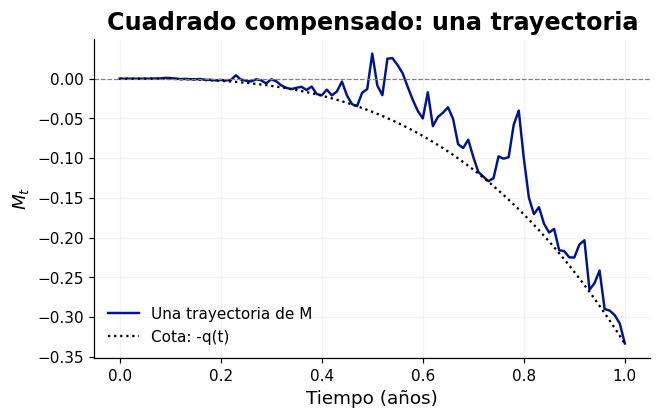

In [5]:
SEED_TRAYECTORIA = 20260205
rng_path = np.random.default_rng(SEED_TRAYECTORIA)
tiempos = np.linspace(0.0, 1.0, 101)
q_grid = tiempos**3 / 3.0
dq = np.diff(q_grid)
z_path = rng_path.standard_normal(len(dq))
dA = np.sqrt(dq) * z_path
A_path = np.r_[0.0, np.cumsum(dA)]
M_path = A_path**2 - q_grid
assert np.all(dq > 0) and np.all(M_path >= -q_grid)
assert np.allclose(np.diff(A_path), dA, atol=1e-15, rtol=0)
tabla_pasos = pd.DataFrame({
    "t": tiempos[1:], "q(t)": q_grid[1:], "Delta q": dq,
    "Z": z_path, "Delta A": dA, "A": A_path[1:], "M": M_path[1:],
}, index=np.arange(1, len(tiempos)))
tabla_pasos.index.name = "Paso"
display(tabla_pasos.head(8).style.format("{:.7f}"))
fig, ax = plt.subplots(figsize=(6.2, 4.0))
ax.plot(tiempos, M_path, lw=1.6, label="Una trayectoria de M")
ax.plot(tiempos, -q_grid, ls=":", color="black", label="Cota: -q(t)")
ax.axhline(0, color="grey", ls="--", lw=0.8)
ax.set(title="Cuadrado compensado: una trayectoria", xlabel="Tiempo (años)", ylabel="$M_t$")
ax.legend()
fig.tight_layout()
plt.show()


Una trayectoria puede alejarse de cero y ser asimétrica. Lo que está centrado es la distribución entre réplicas; no se exige que cada camino oscile de forma simétrica ni que vuelva a cero. La curva siempre respeta $M_t\ge-q(t)$.

### 3. Muchas réplicas en $t=1$

De 2.c.2 sabemos que basta simular $Z_k\sim N(0,1)$ y transformar

$$M_1^{(k)}=\frac{Z_k^2-1}{3}.$$

Conservamos los 400.000 pares y la semilla de la comprobación condicional de la resolución anterior, y aprovechamos su muestra terminal para contrastar también la distribución. El error estándar teórico de la media es $\sqrt{(2/9)/400000}\approx0.000745$: no hace falta otra simulación marginal masiva.

Conservaremos también $A_s$ para $s=0.5$, porque al final necesitaremos comparar pasado y futuro. Construimos las mismas réplicas mediante dos incrementos independientes:

$$A_s^{(k)}=\sqrt{q(s)}Z_{s,k},\qquad
A_1^{(k)}=A_s^{(k)}+\sqrt{q(1)-q(s)}Z_{+,k}.$$

Entonces $Z_k=A_1^{(k)}/\sqrt{q(1)}$ es normal estándar y aplicamos la transformación anterior. Cada réplica es independiente de las demás; dentro de ella, $A_s$ y $A_1$ comparten el primer incremento. Este diseño sirve tanto para la distribución terminal como para el contraste condicional, sin duplicar simulaciones.

Comparamos media, varianza y mínimo con $0$, $2/9$ y la cota $-1/3$. El mínimo observado debe estar **por encima** de la cota; no tiene por qué alcanzarla. Para la media, el teorema central del límite da el intervalo aproximado

$$\overline M\pm1.96\,\frac{s_M}{\sqrt N},$$

con $s_M$ la desviación típica muestral. El 95 % describe la cobertura en repeticiones del experimento, no una garantía para cualquier semilla.

In [6]:
N_TERMINAL = 400_000
SEED_REPLICAS = 20260206
rng_rep = np.random.default_rng(SEED_REPLICAS)
s = 0.5
qs, q1 = s**3/3.0, 1.0/3.0
A_s = np.sqrt(qs) * rng_rep.standard_normal(N_TERMINAL)
A_t = A_s + np.sqrt(q1-qs) * rng_rep.standard_normal(N_TERMINAL)
Z = A_t / np.sqrt(q1)
M1 = (Z**2-1.0)/3.0
M_s = A_s**2-qs
M_t = M1
assert np.allclose(M1, A_t**2-q1, atol=1e-14, rtol=0)
media_emp = M1.mean()
var_emp = M1.var(ddof=1)
se_media = np.sqrt(var_emp/N_TERMINAL)
lo_media, hi_media = media_emp-1.96*se_media, media_emp+1.96*se_media
assert M1.min() >= -q1
assert abs(media_emp) < 5*se_media
# E[(Z²-1)^4] = 105-4*15+6*3-4*1+1 = 60 (momentos normales).
# Momento central cuarto de M1: 60*q1**4; SE asintótico de la varianza.
se_var_teorica = np.sqrt((60*q1**4-(2*q1**2)**2)/N_TERMINAL)
assert abs(var_emp-2/9) < 5*se_var_teorica
tabla_momentos = pd.DataFrame({
    "Teoría": [0, 2/9, -1/3],
    "Simulación": [media_emp, var_emp, M1.min()],
}, index=["Media", "Varianza", "Cota / mínimo observado"])
display(tabla_momentos.style.format("{:+.9f}"))
print(f"IC 95 % aproximado de la media: [{lo_media:+.6f}; {hi_media:+.6f}]")
print(f"Error de la media: {media_emp/se_media:+.2f} errores estándar")
print(f"Error de la varianza: {(var_emp-2/9)/se_var_teorica:+.2f} errores estándar")
print(f"Distancia del mínimo a la cota: {M1.min()+q1:.3e}")
# Convergencia usando prefijos de la misma muestra, sin nuevas simulaciones.
tamanos = np.array([1_000, 5_000, 20_000, 100_000, N_TERMINAL])
tabla_convergencia = pd.DataFrame({
    "N": tamanos,
    "Media": [M1[:n].mean() for n in tamanos],
    "Varianza": [M1[:n].var(ddof=1) for n in tamanos],
    "SE media teórico": np.sqrt((2/9)/tamanos),
}).set_index("N")
display(tabla_convergencia.style.format("{:.6f}"))


,Teoría,Simulación
Media,+0.000000000,-0.000607552
Varianza,+0.222222222,+0.222352075
Cota / mínimo observado,-0.333333333,-0.333333333


IC 95 % aproximado de la media: [-0.002069; +0.000854]
Error de la media: -0.81 errores estándar
Error de la varianza: +0.10 errores estándar
Distancia del mínimo a la cota: 9.359e-12


,Media,Varianza,SE media teórico
N,,,
1000,0.002318,0.196722,0.014907
5000,0.005762,0.221842,0.006667
20000,-0.002836,0.209787,0.003333
100000,0.001235,0.224612,0.001491
400000,-0.000608,0.222352,0.000745


### 4. Contrastar la distribución completa

Los errores de los momentos se expresan en errores estándar. La tabla de prefijos permite observar la estabilización de la muestra: la convergencia no exige que cada error disminuya monótonamente al añadir observaciones.

El histograma contrasta la densidad; la CDF compara probabilidades acumuladas. La densidad diverge de forma integrable junto a $-1/3$, por lo que la curva se dibuja ligeramente a su derecha. Limitamos la vista al percentil 99,5 %, pero normalizamos el histograma con **toda** la muestra y todos los cálculos utilizan también su cola.

Además mostramos cuantiles y la distancia de Kolmogórov–Smirnov (KS), comparando $3M_1+1$ con $\chi^2_1$. El parámetro de la ley es conocido; no se ha ajustado con estos datos. Un valor p alto es compatibilidad con la teoría, no una prueba de que el simulador sea correcto.

KS: D=0.00159, p=0.2666


,Teórico,Simulado
Probabilidad,,
0.010000,-0.333281,-0.333283
0.050000,-0.332023,-0.332016
0.500000,-0.181688,-0.182260
0.950000,+0.947153,+0.948118
0.990000,+1.878299,+1.883280


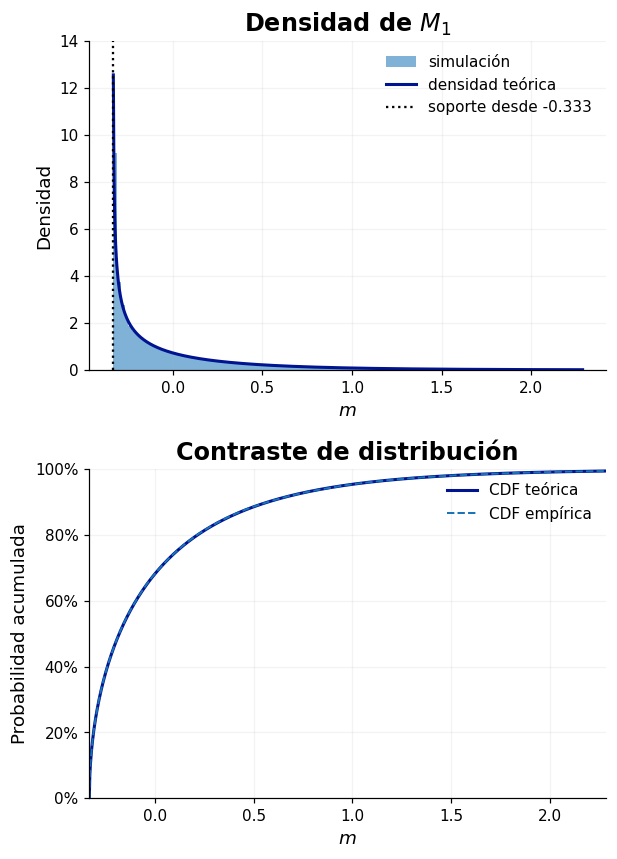

In [7]:
transformada_chi2 = M1 / q1 + 1.0
ks = kstest(transformada_chi2, "chi2", args=(1,))

niveles = np.array([0.01, 0.05, 0.50, 0.95, 0.99])
cuantiles = pd.DataFrame({
    "Teórico": q1 * (chi2.ppf(niveles, 1) - 1.0),
    "Simulado": np.quantile(M1, niveles),
}, index=niveles)
cuantiles.index.name = "Probabilidad"

print(f"KS: D={ks.statistic:.5f}, p={ks.pvalue:.4f}")
display(cuantiles.style.format("{:+.6f}"))

m_max = np.quantile(M1, 0.995)
# La densidad diverge de forma integrable en -q. Se inicia la curva
# ligeramente a la derecha para no aplastar la región informativa.
m_grid = np.linspace(-q1 + 0.003, m_max, 800)
densidad = chi2.pdf(m_grid / q1 + 1.0, 1) / q1

fig, axes = plt.subplots(2, 1, figsize=(5.8, 8.0))
counts, edges = np.histogram(M1, bins=120, range=(-q1, m_max))
axes[0].stairs(counts/(N_TERMINAL*np.diff(edges)), edges, fill=True,
               alpha=0.55, color="#1973b8", label="simulación")
axes[0].plot(m_grid, densidad, color="#001391", lw=2,
             label="densidad teórica")
axes[0].axvline(-q1, color="black", ls=":", lw=1.5,
                label=f"soporte desde {-q1:.3f}")
axes[0].set(title="Densidad de $M_1$",
            xlabel="$m$", ylabel="Densidad", ylim=(0, 14))
axes[0].legend()

m_cdf = np.linspace(-q1, m_max, 1_000)
cdf_teorica = chi2.cdf(m_cdf/q1 + 1.0, 1)
ordenada = np.sort(M1)
idx = np.linspace(0, len(ordenada)-1, 2_000, dtype=int)
cdf_empirica = (idx + 1) / len(ordenada)
axes[1].plot(m_cdf, cdf_teorica, color="#001391", lw=2,
             label="CDF teórica")
axes[1].plot(ordenada[idx], cdf_empirica, color="#1973b8", lw=1.3,
             ls="--", label="CDF empírica")
axes[1].set(title="Contraste de distribución",
            xlabel="$m$", ylabel="Probabilidad acumulada",
            xlim=(-q1, m_max), ylim=(0, 1))
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].legend()

fig.tight_layout()
plt.show()


### 5. Volver a la propiedad de martingala

Una media terminal próxima a cero no verifica por sí sola una martingala. La afirmación de 2.c.1 es más fuerte:

$$E[M_t\mid\mathcal F_s]=M_s.$$

Reutilizamos los pares $(M_s,M_1)$ ya construidos, con $s=0.5$. En cada réplica,

$$M_1-M_s=2A_s\Delta A+(\Delta A)^2-(q(1)-q(s)).$$

Condicionado al pasado, $\Delta A$ es independiente, centrado y tiene varianza $q(1)-q(s)$. Los dos términos esperados se cancelan. Esta es exactamente la demostración condicional de 2.c.1.

Para comprobarla empíricamente agrupamos por quintiles de $M_s$: el incremento medio de cada grupo debería ser compatible con cero. Una regresión de $M_1$ sobre $M_s$ debería tener intercepto cero y pendiente uno. Como la varianza condicional depende de $A_s^2$, mostramos errores estándar robustos a heterocedasticidad (HC1).

La agrupación solo observa una parte de $\mathcal F_s$: es un diagnóstico finito. Ni la regresión ni los quintiles sustituyen la prueba para toda la información y todos los tiempos. Los intervalos del gráfico son puntuales, no simultáneos.

,Teoría,Estimación,SE robusto,IC95 inferior,IC95 superior
Intercepto,+0.000000,-0.000556,+0.000740,-0.002007,+0.000894
Pendiente,+1.000000,+1.001494,+0.017273,+0.967638,+1.035349


,M_s_medio,incremento_medio,n,SE incremento,z
Grupo,,,,,
0,-0.040782,+0.000877,80000,0.001465,+0.60
1,-0.035219,+0.000920,80000,0.001513,+0.61
2,-0.022270,-0.003036,80000,0.001525,-1.99
3,+0.004473,-0.002403,80000,0.001667,-1.44
4,+0.093541,+0.000859,80000,0.002034,+0.42


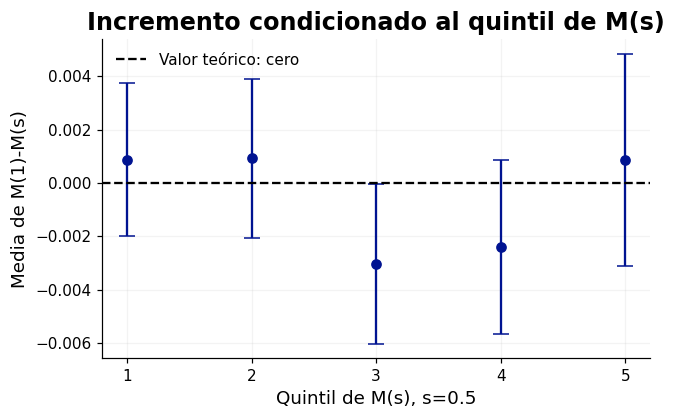

Máximo desvío condicional: 1.99 SE


In [8]:
incremento = M_t-M_s
Xreg = np.column_stack([np.ones(N_TERMINAL), M_s])
intercepto, pendiente = np.linalg.lstsq(Xreg, M_t, rcond=None)[0]
residuos = M_t-Xreg @ np.array([intercepto, pendiente])
bread = np.linalg.inv(Xreg.T @ Xreg)
meat = (Xreg*residuos[:, None]).T @ (Xreg*residuos[:, None])
cov_hc1 = N_TERMINAL/(N_TERMINAL-2) * bread @ meat @ bread
se_coef = np.sqrt(np.diag(cov_hc1))
display(pd.DataFrame({
    "Teoría": [0, 1], "Estimación": [intercepto, pendiente],
    "SE robusto": se_coef,
    "IC95 inferior": np.array([intercepto, pendiente])-1.96*se_coef,
    "IC95 superior": np.array([intercepto, pendiente])+1.96*se_coef,
}, index=["Intercepto", "Pendiente"]).style.format("{:+.6f}"))
grupos = pd.qcut(M_s, 5, labels=False)
tabla_cond = pd.DataFrame({
    "M_s": M_s, "Incremento": incremento, "Grupo": grupos,
}).groupby("Grupo").agg(
    M_s_medio=("M_s", "mean"), incremento_medio=("Incremento", "mean"),
    n=("Incremento", "size"), sd=("Incremento", "std"),
)
tabla_cond["SE incremento"] = tabla_cond.sd/np.sqrt(tabla_cond.n)
tabla_cond["z"] = tabla_cond.incremento_medio/tabla_cond["SE incremento"]
assert np.all(np.abs((np.array([intercepto,pendiente])-[0,1])/se_coef) < 5)
assert np.max(np.abs(tabla_cond.z)) < 5
display(tabla_cond[["M_s_medio", "incremento_medio", "n", "SE incremento", "z"]]
        .style.format({"M_s_medio":"{:+.6f}", "incremento_medio":"{:+.6f}",
                       "SE incremento":"{:.6f}", "z":"{:+.2f}"}))
fig, ax = plt.subplots(figsize=(6.2,4.0))
ax.errorbar(np.arange(1,6), tabla_cond.incremento_medio,
            yerr=1.96*tabla_cond["SE incremento"], fmt="o", capsize=5)
ax.axhline(0, color="black", ls="--", label="Valor teórico: cero")
ax.set(title="Incremento condicionado al quintil de M(s)",
       xlabel="Quintil de M(s), s=0.5", ylabel="Media de M(1)-M(s)", xticks=range(1,6))
ax.legend()
fig.tight_layout()
plt.show()
print(f"Máximo desvío condicional: {np.max(np.abs(tabla_cond.z)):.2f} SE")


**Interpretación conjunta.** Los momentos, la CDF y los cuantiles contrastan la ley marginal; los incrementos agrupados y la regresión contrastan la relación entre pasado y futuro. Son comprobaciones distintas sobre la misma muestra. La justificación de que el proceso es una martingala verdadera sigue siendo la demostración de 2.c.1.

En esta muestra, el máximo desvío por quintil es 1,99 errores estándar: el tercer intervalo puntual del 95 % queda ligeramente fuera de cero. No se exige que los cinco intervalos puntuales contengan cero simultáneamente. La pendiente y el intercepto son compatibles con uno y cero, respectivamente; estos diagnósticos respaldan, pero no demuestran, la identidad condicional.

---

## Conclusiones

- En el cociente $X/N$, la corrección de drift contiene la covariación entre brownianos: $\mu=\sigma\rho-1/2$.
- La integral del apartado 2.b se reduce exactamente al tercer polinomio de Hermite escalado, $W_t^3/3-tW_t$.
- $M_t$ es el cuadrado compensado de una martingala gaussiana. Su ley es una $\chi_1^2$ desplazada y escalada, con media cero y varianza $2t^6/9$.
- Las simulaciones contrastan por separado la identidad de Itô, la distribución terminal y la propiedad condicional de martingala.


In [9]:
print("=" * 76)
print("RESUMEN EJERCICIO 2")
print("=" * 76)
print("2.a  mu = sigma*rho - 1/2")
print("2.b  I_t = W_t^3/3 - t W_t;  Var(I_t) = 2 t^3/3")
print(f"2.c  t=1: E[M_1]=0, Var(M_1)=2/9={2/9:.6f}")
print(f"     Simulación: media={media_emp:+.6f}, varianza={var_emp:.6f}")
print(f"     Contraste condicional: alfa={intercepto:+.5f}, beta={pendiente:.5f}")


RESUMEN EJERCICIO 2
2.a  mu = sigma*rho - 1/2
2.b  I_t = W_t^3/3 - t W_t;  Var(I_t) = 2 t^3/3
2.c  t=1: E[M_1]=0, Var(M_1)=2/9=0.222222
     Simulación: media=-0.000608, varianza=0.222352
     Contraste condicional: alfa=-0.00056, beta=1.00149


## Cobertura del enunciado

Cada fila identifica las celdas de este notebook por su ID estable.

| Apartado del enunciado | Notebook / celdas que responden | Estado |
|---|---|---|
| 2.a · Deriva del cociente y martingala verdadera | Ejercicio 2: `be851f40; bc48b4fc` | PASS |
| 2.b · Integral de Itô resuelta y comprobada | Ejercicio 2: `38b17728; 8f33c00a; 279a5458` | PASS |
| 2.c.1 · Dos métodos y demostración de martingala verdadera | Ejercicio 2: `26362b59` | PASS |
| 2.c.2 · Ley, esperanza, varianza y soporte | Ejercicio 2: `d443c12b` | PASS |
| 2.c.3 · Algoritmo y trayectoria simulada | Ejercicio 2: `simulacion-algoritmo; simulacion-trayectoria` | PASS |
| 2.c.3 · Verificación empírica en t=1: momentos y distribución | Ejercicio 2: `simulacion-momentos; simulacion-ley` | PASS |
| Comprobación adicional · Esperanza condicional | Ejercicio 2: `simulacion-condicional-teoria; simulacion-condicional` | PASS |

Este notebook incluye los datos, las explicaciones, los cálculos y las figuras necesarios para su ejercicio. Puede ejecutarse desde un kernel limpio sin archivos auxiliares. El uso de Jupyter para la simulación cuenta con la autorización docente comunicada por el alumno.